In [291]:
import pandas as pd
import seqclone.util as ut
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'legend.fontsize': 10,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }

mpl.rcParams.update(params)

sns.set_style("ticks")
sns.set_context(context='paper')
savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": False}
mpl.rc('savefig', dpi=300)
output_dir='figures/10.14.20'
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20) 
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [276]:
adata = sc.read_h5ad('Current.h5ad')
df = ut.getCellByGeneMatrix(adata)

/Users/mswift/miniconda3/envs/seqclone/lib/python3.8/site-packages/anndata/compat/__init__.py:158: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/Users/mswift/miniconda3/envs/seqclone/lib/python3.8/site-packages/anndata/compat/__init__.py:158: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


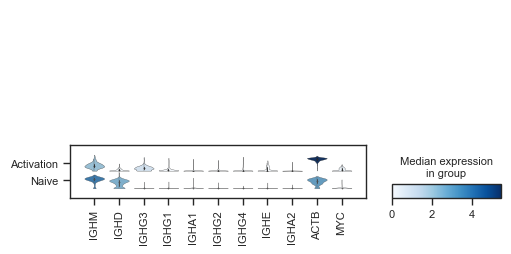

In [277]:
adata.obs['Division_Category'] = adata.obs.Division_Number.astype('category')

IgH_genes = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', 'IGHA1', "IGHG2", 'IGHG4','IGHE', 'IGHA2', 'ACTB', 'MYC']

sc.pl.stacked_violin(adata, var_names = IgH_genes, groupby='Treatment', inner='box', save='TreatmentSwitchTx')

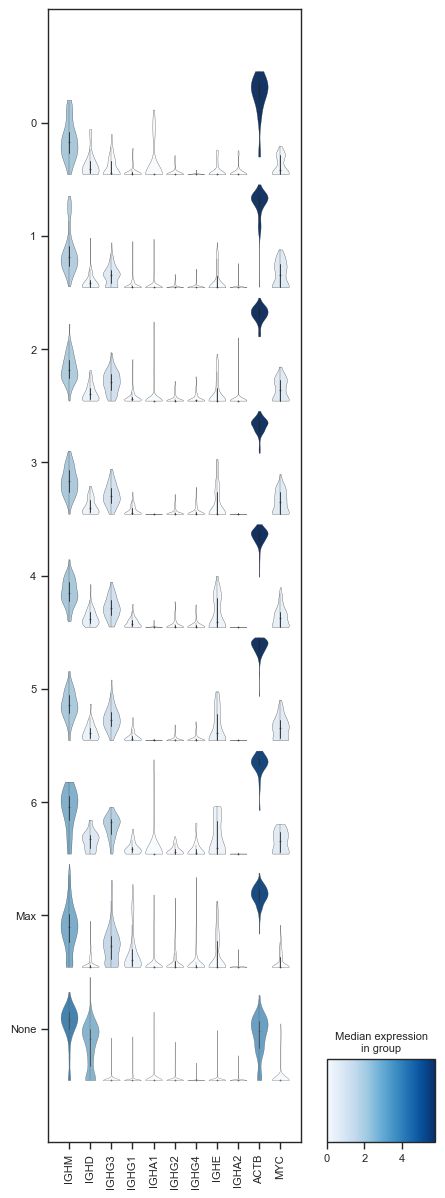

In [278]:
# Filter to no Naive
sc.pl.stacked_violin(adata, var_names = IgH_genes, groupby = 'Division_Category', save='DivisionSwitchTx', inner = 'box',  figsize=[5,15])

In [279]:
sc.tl.dendrogram(adata, groupby='Division_Category', var_names = ['IL4R', 'PRDM1', 'IGHE', 'CD40', 'PAX5'])

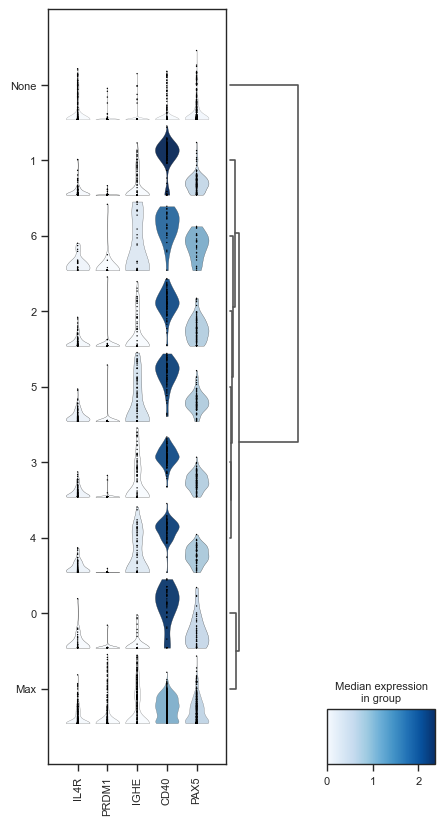

In [280]:
sc.pl.stacked_violin(adata, var_names = ['IL4R', 'PRDM1', 'IGHE', 'CD40', 'PAX5'], groupby='Division_Category', save='BCellGenesByDivision', stripplot=True,figsize=[5,10], dendrogram=True )

In [281]:
sns.set_context('paper')

In [282]:
adata = sc.read_h5ad('../data/CombinedDivisionImmcantation.h5ad')
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata, base = 2)
df = ut.getCellByGeneMatrix(adata)

In [283]:
df.rename_axis(index = {'cell':"index"}, inplace=True)

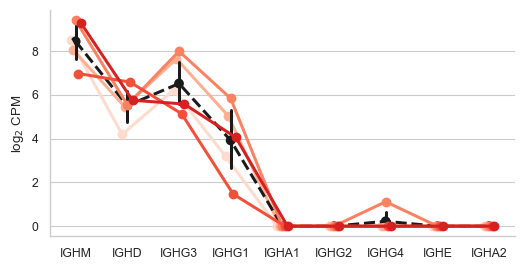

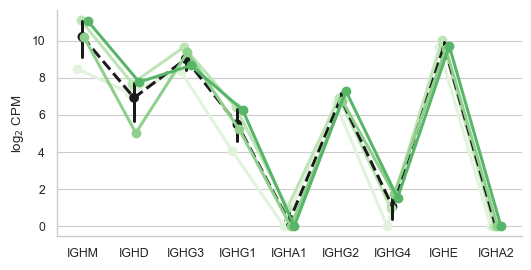

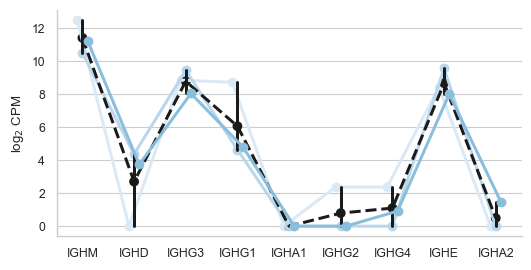

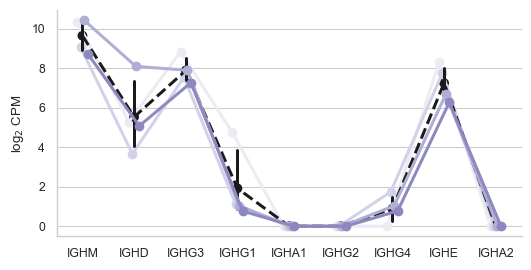

In [284]:
import seqclone.util as ut
IgH_genes = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', 'IGHA1', "IGHG2", 'IGHG4','IGHE', 'IGHA2']

clone = adata.obs.CLONE.value_counts().index[13]
clone2 = adata.obs.CLONE.value_counts().index[26]
clone3 = adata.obs.CLONE.value_counts().index[39]
clone4 = adata.obs.CLONE.value_counts().index[33]

data = df[IgH_genes]
# Cell Lists
celllist = adata.obs.index[adata.obs.CLONE == clone ]
celllist2 = adata.obs.index[adata.obs.CLONE == clone2]
celllist3 = adata.obs.index[adata.obs.CLONE == clone3]
celllist4 = adata.obs.index[adata.obs.CLONE == clone4]

fig1 , ax1 = ut.plotPointPlotLocus(data, celllist, 'Reds')
fig2, ax2 = ut.plotPointPlotLocus(data, celllist2, 'Greens')
fig3, ax3 = ut.plotPointPlotLocus(data, celllist3, 'Blues')
fig4, ax4 = ut.plotPointPlotLocus(data, celllist4, 'Purples')

In [274]:
save_figure(fig1, "Lineage1")
save_figure(fig2, "Lineage2")
save_figure(fig3, "Lineage3")
save_figure(fig4, "Lineage4")

### How many Switch TX States are there? 

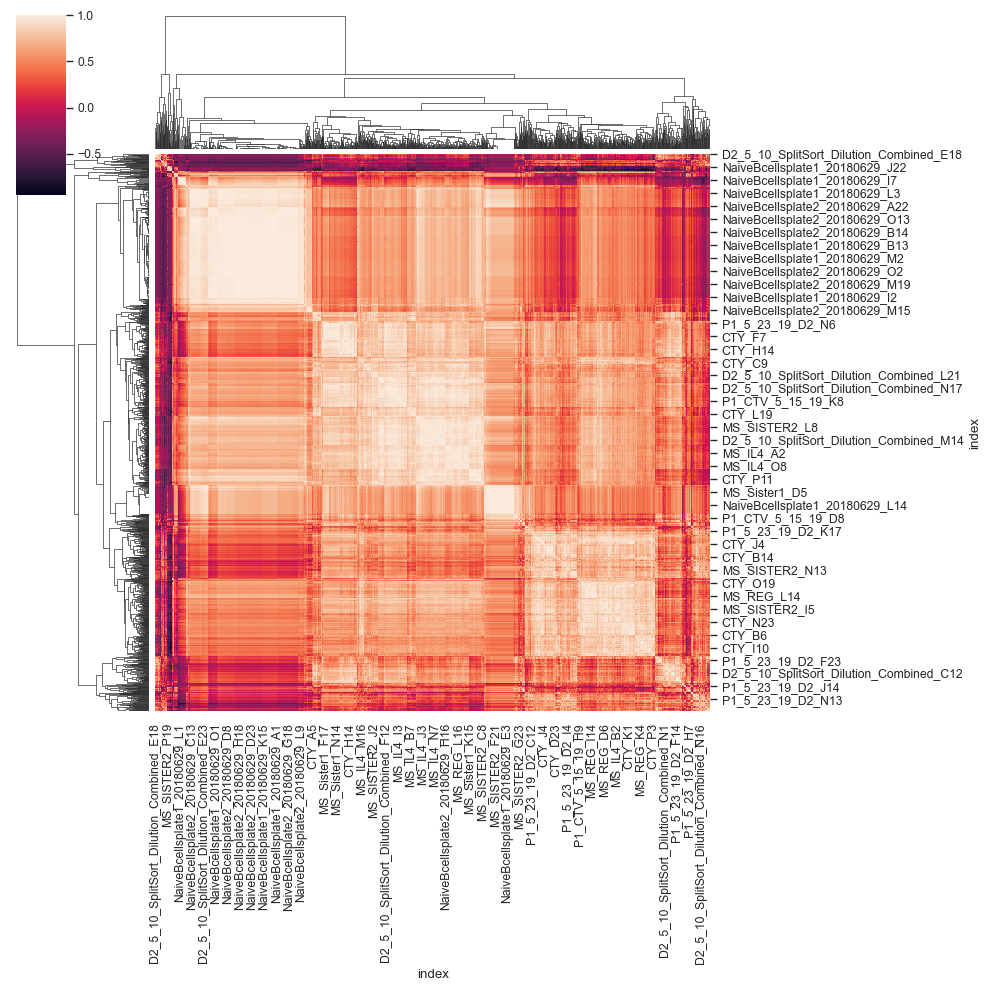

In [287]:
sns.clustermap(df[IgH_genes].T.corr())

## New Figure Design

In [288]:
clonal_comparison = pd.read_csv('../data/ClonalComparison.csv', index_col=0)
# Only Look at Activated and Division Tracked Cells
clonal_comparison = clonal_comparison[clonal_comparison.DivisionSum < 100]
# Division Tweak 
clonal_comparison.DivisionSum.replace(14, 'Max', inplace = True)

_comparisons = clonal_comparison[clonal_comparison.ClonalBool == 0]
_clonal_comparisons = clonal_comparison[clonal_comparison.ClonalBool == 1]


_comparisons = addPearsonofGOIS(df, IgH_genes, _comparisons)
_clonal_comparison = addPearsonofGOIS(df, IgH_genes, _clonal_comparisons)
_comparisons['DivisionSum'] = 'Unrelated'
data = pd.concat([_comparisons, _clonal_comparisons])

label_dict = {0: 'Between Clones', 1 : 'Within Clones'}

data['Label'] = data.ClonalBool.map(label_dict)

<ipython-input-202-7ff68125b3c6>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  divisiondf['Pearson_GeneList'] = result
<ipython-input-288-4006c95930ee>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _comparisons['DivisionSum'] = 'Unrelated'


In [289]:
data['orderer'] = data.DivisionSum.replace('Unrelated', 200)
data['orderer'] = data.orderer.replace('Max', 199)

data = data.sort_values('orderer')

_labels = list(data.orderer.sort_values().unique())

_labels[-1] = 'Between Clones'
_labels[-2] = 'Max Trackable Divisions'

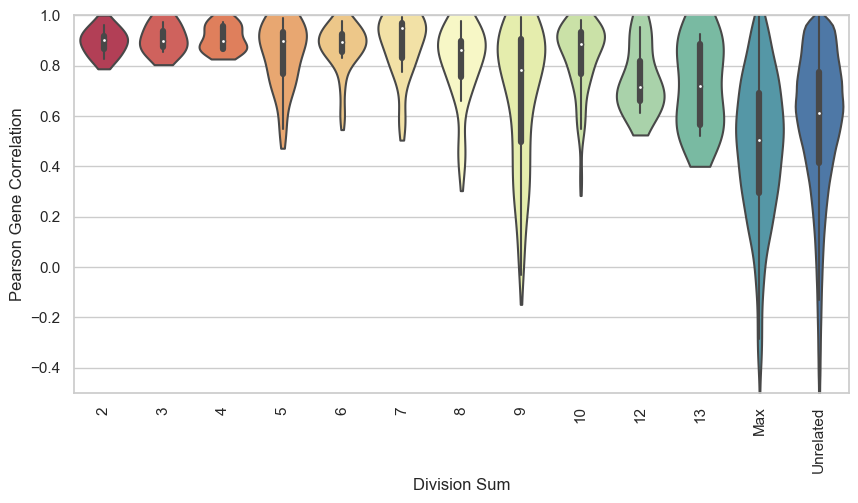

In [294]:
sns.set_context('paper')
sns.set_theme(style="whitegrid")

fig , ax = plt.subplots(1,1, figsize = (10,5))
params = dict(data = data, x = 'DivisionSum', y = 'Pearson_GeneList', cut = True, palette = "Spectral")
p_box = sns.violinplot(**params, scale = 'width')
plt.ylim(-0.5, 1)
plt.xticks(rotation = 90)
plt.xlabel('Division Sum')
plt.ylabel('Pearson Gene Correlation')
plt.title('')
save_figure(fig, "Violin_DivisionSUM_PearsonIgH")

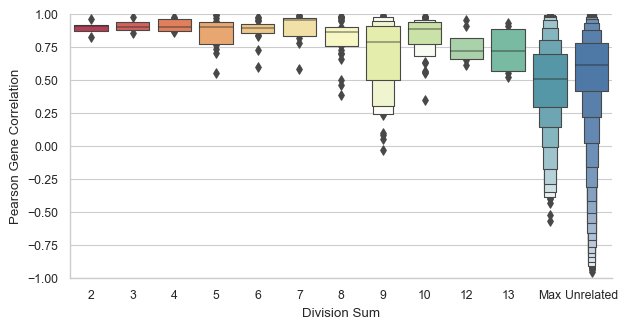

In [295]:
sns.set_context('paper')
sns.set_style()

fig , ax = plt.subplots(1,1, figsize = (7,3.5))
params = dict(data = data, x = 'DivisionSum', y = 'Pearson_GeneList', palette = "Spectral")
p_box = sns.boxenplot(**params, scale = 'area')
#p_strip = sns.stripplot(**params, size = 1, linewidth=0.5)
sns.despine()
plt.ylim(-1, 1)
plt.xticks(rotation = 0)
plt.xlabel('Division Sum')
plt.ylabel('Pearson Gene Correlation')
plt.title('')
save_figure(fig, "Boxen_DivisionSUM_PearsonIgH")

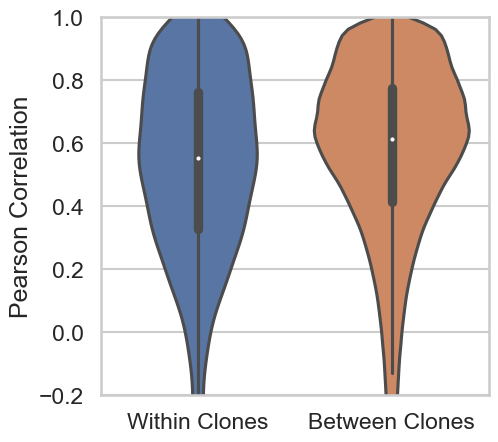

In [296]:
sns.set_context('talk')

fig , ax = plt.subplots(1,1, figsize = (5,5))
params = dict(data = data, x = 'Label', y = 'Pearson_GeneList', palette = 'deep', cut = True)
p_box = sns.violinplot(**params)
plt.ylim(-0.2, 1)
#sns.despine(trim=True)
plt.xlabel('')
plt.ylabel('Pearson Correlation')
plt.title('')
save_figure(fig, "Violin_PearsonIgHDistances")

In [297]:
Between_distances = data[data.Label == 'Between Clones'].Pearson_GeneList.values
Within_distances = data[data.Label != 'Between Clones'].Pearson_GeneList.values
scipy.stats.ks_2samp(data1 = Between_distances, data2 = Within_distances)

KstestResult(statistic=0.0960336039059147, pvalue=2.2813371765613977e-11)

## Clonal Genes

In [198]:
clonal_tests = pd.read_csv('../outputs/BCellsCloneTests/CLONE_tests.csv', index_col=0)

In [54]:
import statsmodels

In [129]:
#for _df in [df1, df2,df3,df4]:
for _df in [df3, df4]:
    _df['significant'], _df['bh_corrected'], _df['alphaSidak'], _df['alphaBonf'] = statsmodels.stats.multitest.multipletests(_df.pvalue.values, method='fdr_bh', alpha = 0.1)
    #_df['significant'] = statsmodels.stats.multitest.multipletests(_df.pvalue.values, method='fdr_bh')[0]

In [130]:
#clone_tests = pd.concat([df1, df2,df3,df4])
clone_tests = pd.concat([df3, df4])

In [32]:
adata = sc.read_h5ad('Current.h5ad')

In [195]:
clonal_genes.to_csv('clonal_genes_rescue_sig.csv')

In [ ]:
_df['significant'], _df['bh_corrected'], _df['alphaSidak'], _df['alphaBonf'] = statsmodels.stats.multitest.multipletests(_df.pvalue.values, method='fdr_bh', alpha = 0.1)